In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Bird parameters
Ab = 0.01      # body coefficient
Aw = 0.02      # wing coefficient
B = 0.01       # induced power coefficient
m = 0.1        # bird mass (kg)
g = 9.81       # gravitational acceleration (m/s^2)

In [3]:
def average_power(x, v):
    return Ab*v**3 + x*Aw*v**3 + (B*m**2*g**2)/(x*v)


P=A_bv^3+xA_wv^3+(Bm^2g^2)/(xv)

In [4]:
def energy(x, v):
    return average_power(x, v) / v

In [5]:
x = 0.5
v = 10

P = average_power(x, v)
E = energy(x, v)

print("Flapping fraction:", x)
print("Gliding fraction:", 1 - x)
print("Speed:", v, "m/s")
print("Average power:", P)
print("Energy per unit distance:", E)

Flapping fraction: 0.5
Gliding fraction: 0.5
Speed: 10 m/s
Average power: 20.001924722
Energy per unit distance: 2.0001924721999997


50% flapping
50% gliding

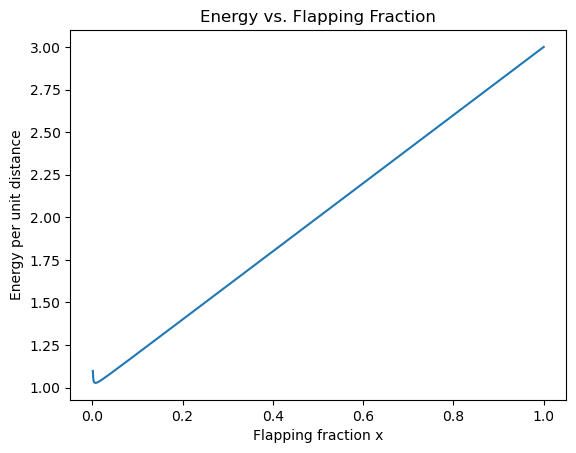

In [15]:
x_values = np.linspace(0.001, 1, 1000)

v = 10

energy_values = energy(x_values, v)

plt.plot(x_values, energy_values)

plt.xlabel("Flapping fraction x")
plt.ylabel("Energy per unit distance")
plt.title("Energy vs. Flapping Fraction")

plt.show()

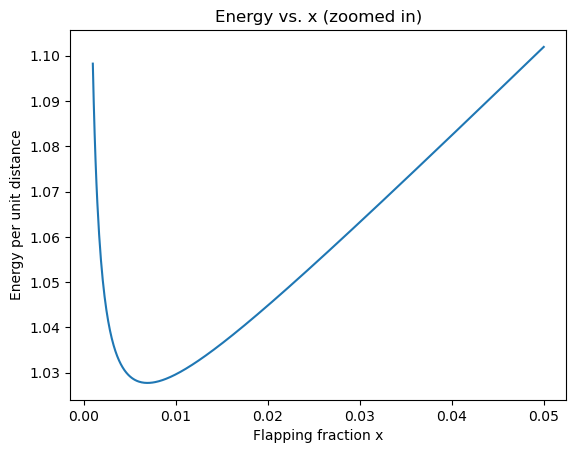

In [16]:
x = np.linspace(0.001, 0.05, 500)

plt.plot(x, energy(x, 10))

plt.xlabel("Flapping fraction x")
plt.ylabel("Energy per unit distance")
plt.title("Energy vs. x (zoomed in)")

plt.show()

In [17]:
min_index = np.argmin(energy_values)

best_x = x_values[min_index]
minimum_energy = energy_values[min_index]

print("Optimal flapping fraction:", best_x)
print("Optimal gliding fraction:", 1 - best_x)
print("Minimum energy per unit distance:", minimum_energy)

Optimal flapping fraction: 0.007
Optimal gliding fraction: 0.993
Minimum energy per unit distance: 1.0277480142857143


In [18]:
x_theoretical = (m * g / v**2) * np.sqrt(B / Aw)

print("Theoretical optimal x:", x_theoretical)
print("Python optimal x:", best_x)

Theoretical optimal x: 0.006936717523440032
Python optimal x: 0.007


The reason for the difference is that Python scans x across the 1,000 points we created, rather than continuously.

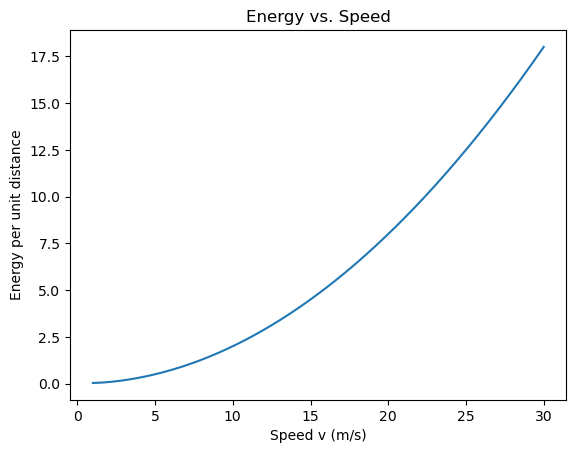

In [19]:
x = 0.5

v_values = np.linspace(1, 30, 500)
energy_vs_speed = energy(x, v_values)

plt.plot(v_values, energy_vs_speed)

plt.xlabel("Speed v (m/s)")
plt.ylabel("Energy per unit distance")
plt.title("Energy vs. Speed")

plt.show()

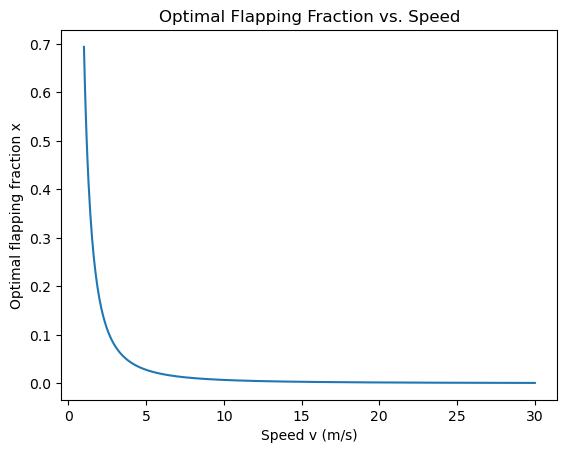

In [20]:
v_values = np.linspace(1, 30, 500)

optimal_x_values = (m * g / v_values**2) * np.sqrt(B / Aw)

plt.plot(v_values, optimal_x_values)

plt.xlabel("Speed v (m/s)")
plt.ylabel("Optimal flapping fraction x")
plt.title("Optimal Flapping Fraction vs. Speed")

plt.show()

Slow Flight
v down -> x up
flapping fraction get bigger

Fast Flight
v up -> x down
flapping fraction gets smaller